## From Lab to Life: SVSNet-Based
Zero-Calibration AI for Mental Wellness by
Continuous Stress Biomarker Analysis

### Data Curation, Cleaning and Integrity Check 

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# Update for Windows path
root_dir = r"C:\Users\suyas\SVSNet\Dataset\UNIVERSE_Refined"
participants = [f"UN_{i}" for i in range(101, 125)]
labs = ["Lab1", "Lab2", "Wild"]

window_duration_sec = 10
eeg_fs = 256
eda_fs = 4
bvp_fs = 64
temp_fs = 4
eeg_window_size = eeg_fs * window_duration_sec
eda_window_size = eda_fs * window_duration_sec
bvp_window_size = bvp_fs * window_duration_sec
temp_window_size = temp_fs * window_duration_sec

valid_tasks = ['arithmetix_easy', 'stroop_easy', 'sudoku_easy', 'n_back_easy',
               'arithmetix_hard', 'stroop_hard', 'sudoku_hard', 'n_back_hard']

data_dict = {}

def extract_wild_label(task_folder_name):
    name = task_folder_name.lower()
    if name.startswith("vlw") or name.startswith("low"):
        return 0
    elif name.startswith("hig") or name.startswith("vhg"):
        return 1
    else:
        return None

def process_one_combination(eeg_path, eda_path, bvp_path, temp_path, label):
    if not all(os.path.exists(p) for p in [eeg_path, eda_path, bvp_path, temp_path]):
        print(f"❌ Missing one or more files at: {eeg_path}, {eda_path}, {bvp_path}, {temp_path}")
        return [], [], [], [], []

    try:
        eeg_data = np.array(pickle.load(open(eeg_path, 'rb')))
        if eeg_data.ndim == 1:
            eeg_data = np.stack(eeg_data, axis=0)
        if eeg_data.ndim != 2 or eeg_data.shape[1] != 4:
            return [], [], [], [], []
    except:
        return [], [], [], [], []

    try:
        eda_data = np.array(pickle.load(open(eda_path, 'rb')))
        if eda_data.ndim == 1:
            eda_data = eda_data.reshape(-1, 1)
        if eda_data.ndim != 2 or eda_data.shape[1] != 1:
            return [], [], [], [], []
    except:
        return [], [], [], [], []

    try:
        bvp_data = np.array(pickle.load(open(bvp_path, 'rb')))
        if bvp_data.ndim == 1:
            bvp_data = bvp_data.reshape(-1, 1)
        if bvp_data.ndim != 2 or bvp_data.shape[1] != 1:
            return [], [], [], [], []
    except:
        return [], [], [], [], []

    try:
        temp_data = np.array(pickle.load(open(temp_path, 'rb')))
        if temp_data.ndim == 1:
            temp_data = temp_data.reshape(-1, 1)
        if temp_data.ndim != 2 or temp_data.shape[1] != 1:
            return [], [], [], [], []
    except:
        return [], [], [], [], []

    num_windows = min(
        eeg_data.shape[0] // eeg_window_size,
        eda_data.shape[0] // eda_window_size,
        bvp_data.shape[0] // bvp_window_size,
        temp_data.shape[0] // temp_window_size
    )

    eeg_out, eda_out, bvp_out, temp_out, labels = [], [], [], [], []
    for i in range(num_windows):
        eeg_win = eeg_data[i * eeg_window_size : (i + 1) * eeg_window_size].T
        eda_win = eda_data[i * eda_window_size : (i + 1) * eda_window_size].T
        bvp_win = bvp_data[i * bvp_window_size : (i + 1) * bvp_window_size].T
        temp_win = temp_data[i * temp_window_size : (i + 1) * temp_window_size].T

        eeg_out.append(eeg_win)
        eda_out.append(eda_win)
        bvp_out.append(bvp_win)
        temp_out.append(temp_win)
        labels.append(label)

    return eeg_out, eda_out, bvp_out, temp_out, labels

for p in participants:
    for lab in labs:
        eeg_all, eda_all, bvp_all, temp_all, labels_all = [], [], [], [], []

        if lab == "Wild":
            lab_dir = os.path.join(root_dir, p, lab, "Preprocessed")
            if not os.path.exists(lab_dir):
                continue
            for task in os.listdir(lab_dir):
                label = extract_wild_label(task)
                if label is None:
                    continue
                task_dir = os.path.join(lab_dir, task)
                eeg_path = os.path.join(task_dir, "EEG_filtered.pickle")
                eda_path = os.path.join(task_dir, "EDA_filtered.pickle")
                bvp_path = os.path.join(task_dir, "BVP_filtered.pickle")
                temp_path = os.path.join(task_dir, "TEMP_filtered.pickle")

                eeg_list, eda_list, bvp_list, temp_list, label_list = process_one_combination(
                    eeg_path, eda_path, bvp_path, temp_path, label
                )
                eeg_all.extend(eeg_list)
                eda_all.extend(eda_list)
                bvp_all.extend(bvp_list)
                temp_all.extend(temp_list)
                labels_all.extend(label_list)

        else:
            label_csv_path = os.path.join(root_dir, p, lab, "Task_Labels.csv")
            if not os.path.exists(label_csv_path):
                print(f"⚠️ Missing CSV: {label_csv_path}")
                continue

            df = pd.read_csv(label_csv_path)
            df['Task'] = df['Task'].str.lower().str.strip()
            df = df[df['Task'].isin(valid_tasks)]
            task_to_score = dict(zip(df['Task'], df['Weighted Nasa Score']))

            preprocessed_dir = os.path.join(root_dir, p, lab, "Preprocessed")
            if not os.path.exists(preprocessed_dir):
                continue
            preprocessed_tasks = os.listdir(preprocessed_dir)

            for task, score in task_to_score.items():
                task_name = task.lower().strip()
                if task_name not in preprocessed_tasks:
                    print(f"⚠️ Task '{task_name}' listed in CSV but missing in folder for {p} {lab}")
                    continue

                if not isinstance(score, (float, int)):
                    continue
                if score < 45:
                    label = 0
                elif score > 55:
                    label = 1
                else:
                    continue

                task_dir = os.path.join(preprocessed_dir, task_name)
                eeg_path = os.path.join(task_dir, "EEG_filtered.pickle")
                eda_path = os.path.join(task_dir, "EDA_filtered.pickle")
                bvp_path = os.path.join(task_dir, "BVP_filtered.pickle")
                temp_path = os.path.join(task_dir, "TEMP_filtered.pickle")

                eeg_list, eda_list, bvp_list, temp_list, label_list = process_one_combination(
                    eeg_path, eda_path, bvp_path, temp_path, label
                )
                eeg_all.extend(eeg_list)
                eda_all.extend(eda_list)
                bvp_all.extend(bvp_list)
                temp_all.extend(temp_list)
                labels_all.extend(label_list)

        key_prefix = f"{p}_{lab}"
        data_dict[f"{key_prefix}_EEG"] = np.array(eeg_all)
        data_dict[f"{key_prefix}_EDA"] = np.array(eda_all)
        data_dict[f"{key_prefix}_BVP"] = np.array(bvp_all)
        data_dict[f"{key_prefix}_TEMP"] = np.array(temp_all)
        data_dict[f"{key_prefix}_Label"] = np.array(labels_all)

        print(f"✅ Processed {key_prefix} | EEG: {len(eeg_all)}, EDA: {len(eda_all)}, BVP: {len(bvp_all)}, TEMP: {len(temp_all)}, Labels: {len(labels_all)}, Distribution: {np.bincount(labels_all) if labels_all else '[]'}")

# Summary
print("\n🎯 Summary of all processed combinations:")
for k in data_dict:
    if "EEG" in k:
        count = data_dict[k].shape[0]
        print(f"{k}: {count} samples")


✅ Processed UN_101_Lab1 | EEG: 480, EDA: 480, BVP: 480, TEMP: 480, Labels: 480, Distribution: [120 360]
✅ Processed UN_101_Lab2 | EEG: 357, EDA: 357, BVP: 357, TEMP: 357, Labels: 357, Distribution: [  0 357]
✅ Processed UN_101_Wild | EEG: 1376, EDA: 1376, BVP: 1376, TEMP: 1376, Labels: 1376, Distribution: [1166  210]
✅ Processed UN_102_Lab1 | EEG: 297, EDA: 297, BVP: 297, TEMP: 297, Labels: 297, Distribution: [  0 297]
✅ Processed UN_102_Lab2 | EEG: 475, EDA: 475, BVP: 475, TEMP: 475, Labels: 475, Distribution: [  0 475]
✅ Processed UN_102_Wild | EEG: 948, EDA: 948, BVP: 948, TEMP: 948, Labels: 948, Distribution: [582 366]
✅ Processed UN_103_Lab1 | EEG: 300, EDA: 300, BVP: 300, TEMP: 300, Labels: 300, Distribution: [  0 300]
✅ Processed UN_103_Lab2 | EEG: 418, EDA: 418, BVP: 418, TEMP: 418, Labels: 418, Distribution: [120 298]
✅ Processed UN_104_Lab1 | EEG: 357, EDA: 357, BVP: 357, TEMP: 357, Labels: 357, Distribution: [  0 357]
✅ Processed UN_104_Lab2 | EEG: 417, EDA: 417, BVP: 417, T

In [2]:
import numpy as np

X_eeg_all, X_eda_all, X_bvp_all, X_temp_all, y_all = [], [], [], [], []

for key in data_dict:
    if key.endswith("_EEG"):
        base = key.replace("_EEG", "")
        eeg = data_dict.get(f"{base}_EEG")
        eda = data_dict.get(f"{base}_EDA")
        bvp = data_dict.get(f"{base}_BVP")
        temp = data_dict.get(f"{base}_TEMP")
        label = data_dict.get(f"{base}_Label")

        if any(x is None for x in [eeg, eda, bvp, temp, label]):
            print(f"⚠️ Skipping {base} - missing one or more arrays")
            continue

        # Validate dimensions
        if eeg.ndim != 3 or eeg.shape[1:] != (4, 2560):
            print(f"⚠️ Skipping {base} - bad EEG shape: {eeg.shape}")
            continue
        if eda.ndim != 3 or eda.shape[1:] != (1, 40):
            print(f"⚠️ Skipping {base} - bad EDA shape: {eda.shape}")
            continue
        if bvp.ndim != 3 or bvp.shape[1:] != (1, 640):
            print(f"⚠️ Skipping {base} - bad BVP shape: {bvp.shape}")
            continue
        if temp.ndim != 3 or temp.shape[1:] != (1, 40):
            print(f"⚠️ Skipping {base} - bad TEMP shape: {temp.shape}")
            continue
        if label.ndim != 1 or len(label) != len(eeg):
            print(f"⚠️ Skipping {base} - bad Label shape: {label.shape} vs EEG {eeg.shape[0]}")
            continue

        X_eeg_all.append(eeg)
        X_eda_all.append(eda)
        X_bvp_all.append(bvp)
        X_temp_all.append(temp)
        y_all.append(label)

# Final concatenation
X_eeg = np.concatenate(X_eeg_all, axis=0)
X_eda = np.concatenate(X_eda_all, axis=0)
X_bvp = np.concatenate(X_bvp_all, axis=0)
X_temp = np.concatenate(X_temp_all, axis=0)
y = np.concatenate(y_all, axis=0)

print("\n✅ Final combined dataset:")
print("X_eeg shape:", X_eeg.shape)
print("X_eda shape:", X_eda.shape)
print("X_bvp shape:", X_bvp.shape)
print("X_temp shape:", X_temp.shape)
print("y shape:", y.shape)
print("Label distribution:", np.bincount(y.astype(int)))


⚠️ Skipping UN_119_Wild - bad EEG shape: (0,)

✅ Final combined dataset:
X_eeg shape: (38017, 4, 2560)
X_eda shape: (38017, 1, 40)
X_bvp shape: (38017, 1, 640)
X_temp shape: (38017, 1, 40)
y shape: (38017,)
Label distribution: [19712 18305]


In [3]:
import numpy as np

def check_integrity(X, std_threshold=1e-3):
    """
    Generic integrity checker for 3D input (N, C, T).
    Flags NaNs, infs, all-zeros, and low-variance channels.
    Returns: list of bad sample indices.
    """
    bad_indices = []
    for i in range(X.shape[0]):
        sample = X[i]
        if not np.isfinite(sample).all():
            bad_indices.append(i)
            continue
        if np.all(sample == 0):
            bad_indices.append(i)
            continue
        flat = False
        for ch in range(sample.shape[0]):
            if np.std(sample[ch]) < std_threshold:
                flat = True
                break
        if flat:
            bad_indices.append(i)
    return bad_indices

# === Step 1: Check all modalities ===
bad_eeg  = set(check_integrity(X_eeg))
bad_eda  = set(check_integrity(X_eda))
bad_bvp  = set(check_integrity(X_bvp))
bad_temp = set(check_integrity(X_temp))

# === Step 2: Union of all bad indices ===
all_bad = bad_eeg | bad_eda | bad_bvp | bad_temp
print(f"❌ Total bad samples (any modality): {len(all_bad)}")

# === Step 3: Filter everything ===
valid_indices = sorted(set(range(len(y))) - all_bad)

X_eeg  = X_eeg[valid_indices]
X_eda  = X_eda[valid_indices]
X_bvp  = X_bvp[valid_indices]
X_temp = X_temp[valid_indices]
y      = y[valid_indices]

# === Step 4: Final report ===
print("✅ All modalities cleaned and synchronized.")
print(f"EEG:  {X_eeg.shape}")
print(f"EDA:  {X_eda.shape}")
print(f"BVP:  {X_bvp.shape}")
print(f"TEMP: {X_temp.shape}")
print(f"Labels: {y.shape} | Distribution: {np.bincount(y.astype(int))}")


❌ Total bad samples (any modality): 2063
✅ All modalities cleaned and synchronized.
EEG:  (35954, 4, 2560)
EDA:  (35954, 1, 40)
BVP:  (35954, 1, 640)
TEMP: (35954, 1, 40)
Labels: (35954,) | Distribution: [18441 17513]


# EEG Preprocessing

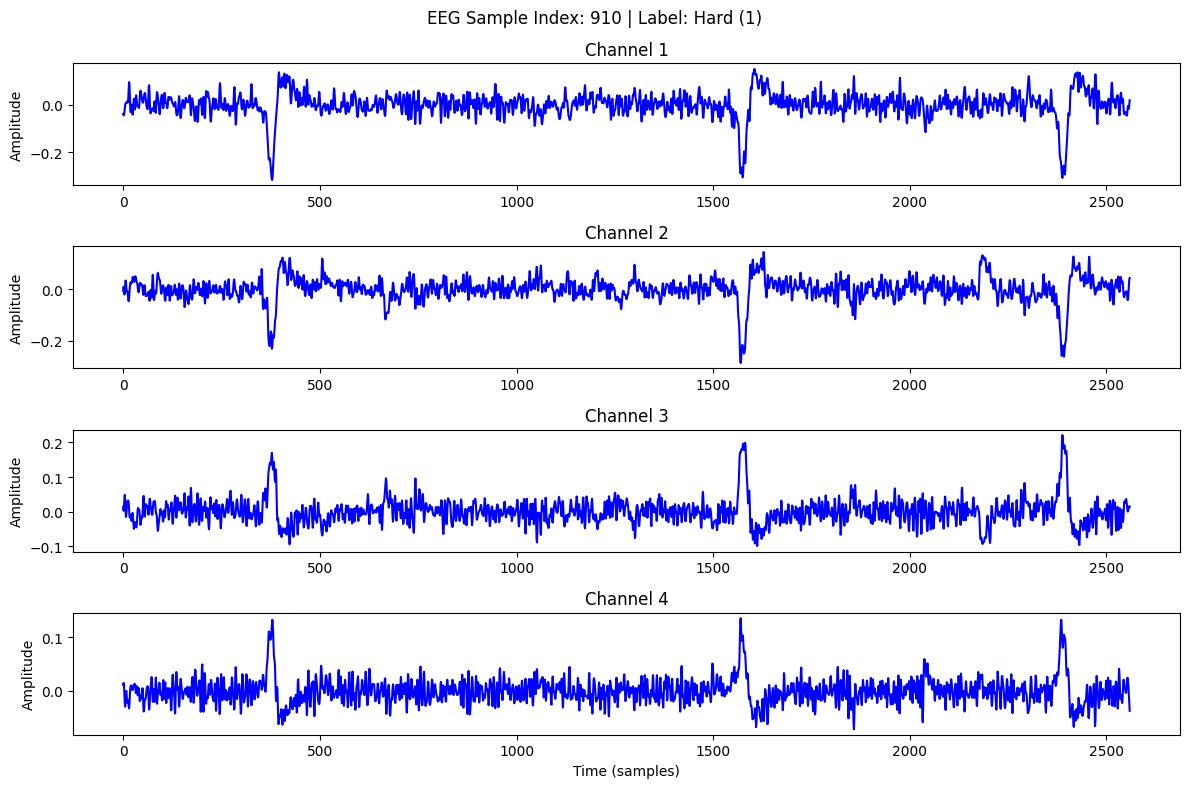

In [11]:
# Initial structure of unprocessed eeg

import matplotlib.pyplot as plt
import numpy as np

# Function to plot one sample of EEG data
def plot_eeg_sample(X_eeg, y, index=0):
    eeg_sample = X_eeg[index]  # shape (4, 2560)
    label = y[index]

    plt.figure(figsize=(12, 8))
    for i in range(4):
        plt.subplot(4, 1, i + 1)
        plt.plot(eeg_sample[i], color='b')
        plt.title(f"Channel {i+1}")
        plt.ylabel("Amplitude")
        if i == 0:
            plt.suptitle(f"EEG Sample Index: {index} | Label: {'Easy (0)' if label == 0 else 'Hard (1)'}")
    plt.xlabel("Time (samples)")
    plt.tight_layout()
    plt.savefig(r"C:\Users\suyas\SVSNet\Preprocessing\EEG_unprocessed_sample.png")
    plt.show()

# View a few samples
plot_eeg_sample(X_eeg, y, index=910)



In [6]:
# Checking for NANs and infs

import numpy as np

def check_eeg_integrity(X_eeg, std_threshold=1e-3):
    """
    Checks for signal issues in EEG data.
    Returns indices of samples to remove.

    Args:
        X_eeg: shape (N, 4, T)
        std_threshold: threshold for near-flat lines

    Returns:
        bad_indices: list of sample indices with issues
    """
    bad_indices = []

    for i in range(X_eeg.shape[0]):
        sample = X_eeg[i]
        if np.isnan(sample).any():
            bad_indices.append(i)
            continue

        if np.all(sample == 0):
            bad_indices.append(i)
            continue

        flat_channel = False
        for ch in range(sample.shape[0]):
            if np.std(sample[ch]) < std_threshold:
                flat_channel = True
                break
        if flat_channel:
            bad_indices.append(i)

    return bad_indices

# Run check
bad_indices = check_eeg_integrity(X_eeg)

print(f"❌ Found {len(bad_indices)} bad EEG samples out of {X_eeg.shape[0]}")


❌ Found 0 bad EEG samples out of 35954


In [7]:
# Convert bad_indices to a set for fast lookup
bad_set = set(bad_indices)

# Get indices to keep
good_indices = [i for i in range(X_eeg.shape[0]) if i not in bad_set]

# Apply filtering
X_eeg_clean = X_eeg[good_indices]
X_eda_clean = X_eda[good_indices]
y_clean = y[good_indices]

# Replace originals if desired
X_eeg = X_eeg_clean
X_eda = X_eda_clean
y = y_clean

print(f"✅ Cleaned dataset: EEG {X_eeg.shape}, EDA {X_eda.shape}, Labels {y.shape}")


✅ Cleaned dataset: EEG (35954, 4, 2560), EDA (35954, 1, 40), Labels (35954,)


In [8]:
# Bandpass Filter from 0.5-45 Hz
from scipy.signal import butter, filtfilt

def bandpass_filter(data, lowcut=0.5, highcut=45.0, fs=256, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=-1)  # apply filter along time axis

# Apply to EEG data shape (N, C, T)
def apply_bandpass_to_eeg(X_eeg, lowcut=0.5, highcut=45.0, fs=256):
    filtered = []
    for sample in X_eeg:
        filtered_sample = bandpass_filter(sample, lowcut, highcut, fs)
        filtered.append(filtered_sample)
    return np.array(filtered)

X_eeg_filtered = apply_bandpass_to_eeg(X_eeg)


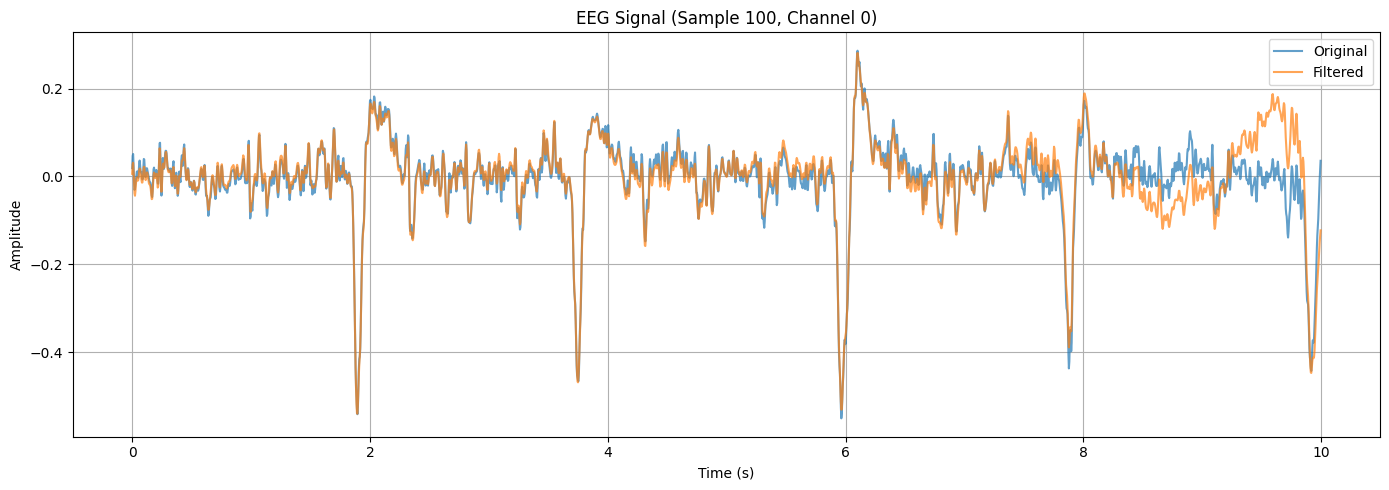

In [9]:
# Visualization before and after bandpass

import matplotlib.pyplot as plt

def visualize_bandpass_effect(original, filtered, fs=256, sample_idx=100, channel=0):
    time = np.arange(original.shape[-1]) / fs  # Time in seconds
    plt.figure(figsize=(14, 5))

    plt.plot(time, original[sample_idx][channel], label="Original", alpha=0.7)
    plt.plot(time, filtered[sample_idx][channel], label="Filtered", alpha=0.7)

    plt.title(f"EEG Signal (Sample {sample_idx}, Channel {channel})")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(r"C:\Users\suyas\SVSNet\Preprocessing\EEG_bandpassed.png")
    plt.show()

# Example: Plot for sample 0, channel 0
visualize_bandpass_effect(X_eeg, X_eeg_filtered, sample_idx=100, channel=0)


In [13]:
import numpy as np
import pywt
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from numba import njit

# === Step 1: Numba-accelerated thresholding ===
@njit
def soft_threshold(arr, threshold):
    return np.sign(arr) * np.maximum(np.abs(arr) - threshold, 0)

# === Step 2: Per-channel DWT denoising ===
def denoise_channel(ch, wavelet='db4', level=4):
    coeffs = pywt.wavedec(ch, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(ch)))
    coeffs_thresh = [coeffs[0]] + [soft_threshold(c, uthresh) for c in coeffs[1:]]
    denoised_ch = pywt.waverec(coeffs_thresh, wavelet)
    return denoised_ch[:len(ch)]

# === Step 3: Per-sample EEG denoising (4 channels) ===
def dwt_denoise_eeg(eeg_sample, wavelet='db4', level=4):
    return np.vstack([denoise_channel(ch, wavelet, level) for ch in eeg_sample])

# === Step 4: Dataset-level parallel denoising using Joblib ===
def denoise_eeg_dataset_dwt(X_eeg, wavelet='db4', level=4, num_workers=6):
    print(f"🚀 Denoising {len(X_eeg)} EEG samples using Joblib with {num_workers} workers...")
    X_eeg_denoised = Parallel(n_jobs=num_workers)(
        delayed(dwt_denoise_eeg)(sample, wavelet, level) for sample in X_eeg
    )
    return np.array(X_eeg_denoised)

# === Step 5: Optional visualization ===
def visualize_dwt_denoising(original, denoised, channel=0):
    plt.figure(figsize=(14, 4))
    plt.plot(original[channel], label='Original (Bandpassed)', alpha=0.7)
    plt.plot(denoised[channel], label='After DWT Denoising', alpha=0.7)
    plt.title(f"EEG Channel {channel+1} - DWT Denoising")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.tight_layout()
    plt.grid(True)
    plt.savefig(r"C:\Users\suyas\SVSNet\Preprocessing\EEG_denoised_sample.png")
    plt.show()

# === Step 6: Apply it ===
X_eeg_denoised = denoise_eeg_dataset_dwt(X_eeg_filtered)
print("✅ Filtered EEG signal has been denoised.")


🚀 Denoising 35954 EEG samples using Joblib with 6 workers...
✅ Filtered EEG signal has been denoised.


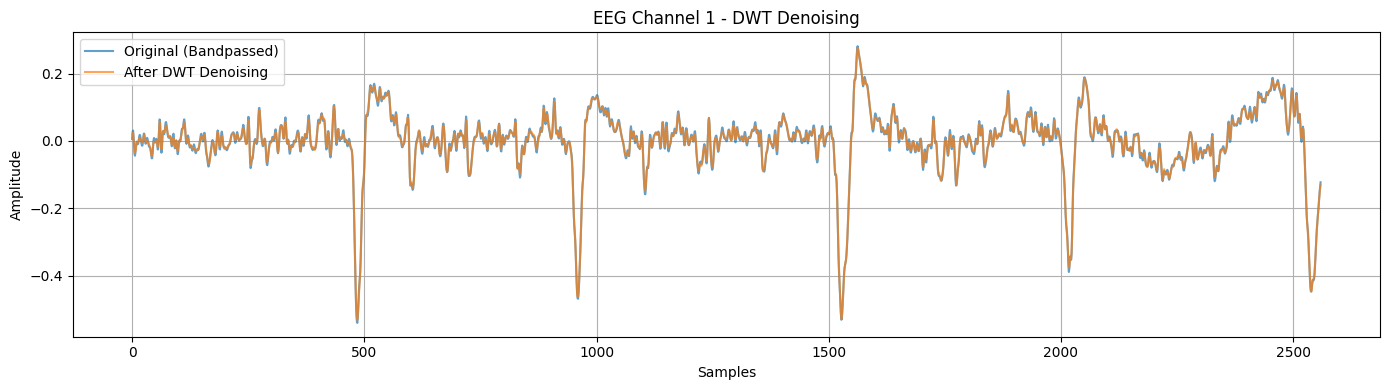

In [14]:
# Visualizing before and after DWT denoising

sample_idx = 100


original_sample = X_eeg_filtered[sample_idx]
denoised_sample = X_eeg_denoised[sample_idx]


visualize_dwt_denoising(original_sample, denoised_sample)


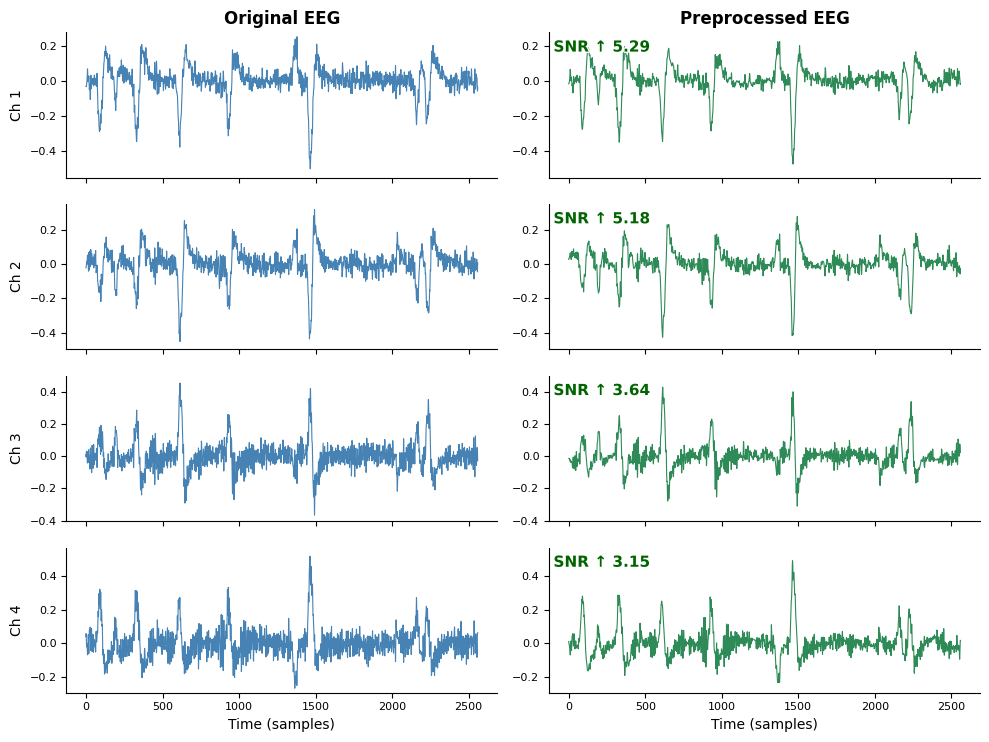

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe  # for text outline

def compare_eeg_samples(X_eeg_orig, X_eeg_denoised, y, index=0, overlay=False):
    """
    Compare original and denoised EEG signals channel-wise, with SNR annotation and compact layout.

    Parameters:
        X_eeg_orig: np.ndarray, shape (N, 4, T)
        X_eeg_denoised: np.ndarray, shape (N, 4, T)
        y: np.ndarray, shape (N,)
        index: int, sample index to visualize
        overlay: bool, if True plots original and denoised on same subplot
    """
    eeg_orig = X_eeg_orig[index]
    eeg_denoised = X_eeg_denoised[index]
    label = y[index]

    if np.allclose(eeg_orig, 0) or np.allclose(eeg_denoised, 0):
        print(f"Warning: Sample #{index} has zero or near-zero EEG signal.")
        return

    n_channels = eeg_orig.shape[0]
    fig_width = 8 if overlay else 10
    fig, axes = plt.subplots(nrows=n_channels, ncols=1 if overlay else 2,
                             figsize=(fig_width, 8), sharex=True)

    if n_channels == 1:
        axes = np.expand_dims(axes, axis=0)

    task_label = 'Low Workload (Easy)' if label == 0 else 'High Workload (Hard)'
    # fig.suptitle(f"EEG Signal Comparison (Sample #{index}) - {task_label}",
    #              fontsize=14, fontweight='bold', y=1.02)

    for ch in range(n_channels):
        signal = eeg_denoised[ch]
        noise = eeg_orig[ch] - eeg_denoised[ch]
        snr = np.std(signal) / (np.std(noise) + 1e-6)

        time = np.arange(eeg_orig[ch].shape[0])

        if overlay:
            ax = axes[ch]
            ax.plot(time, eeg_orig[ch], label='Original', color='steelblue', linewidth=0.8)
            ax.plot(time, eeg_denoised[ch], label='Denoised', color='seagreen', linewidth=0.8)
            ax.set_ylabel(f"Ch {ch+1}", fontsize=10)
            ax.legend(fontsize=8, loc='upper right')

            # SNR label (top-left)
            ax.text(0.01, 0.95,
                    f"SNR ↑ {snr:.2f}",
                    transform=ax.transAxes,
                    fontsize=11,
                    fontweight='bold',
                    color='darkgreen',
                    ha='left',
                    va='top',
                    path_effects=[pe.withStroke(linewidth=2, foreground='white')])
        else:
            # Original EEG
            axes[ch, 0].plot(time, eeg_orig[ch], color='steelblue', linewidth=0.8)
            axes[ch, 0].set_ylabel(f"Ch {ch+1}", fontsize=10)
            if ch == 0:
                axes[ch, 0].set_title("Original EEG", fontsize=12, fontweight='bold')

            # Denoised EEG
            axes[ch, 1].plot(time, eeg_denoised[ch], color='seagreen', linewidth=0.8)
            if ch == 0:
                axes[ch, 1].set_title("Preprocessed EEG", fontsize=12, fontweight='bold')

            # SNR label (top-left)
            axes[ch, 1].text(0.01, 0.95,
                             f"SNR ↑ {snr:.2f}",
                             transform=axes[ch, 1].transAxes,
                             fontsize=11,
                             fontweight='bold',
                             color='darkgreen',
                             ha='left',
                             va='top',
                             path_effects=[pe.withStroke(linewidth=2, foreground='white')])

            # Y-limits
            ymin = min(eeg_orig[ch].min(), eeg_denoised[ch].min()) * 1.1
            ymax = max(eeg_orig[ch].max(), eeg_denoised[ch].max()) * 1.1
            axes[ch, 0].set_ylim([ymin, ymax])
            axes[ch, 1].set_ylim([ymin, ymax])

    # X-axis labels
    if overlay:
        axes[-1].set_xlabel("Time (samples)", fontsize=10)
    else:
        for ax in axes[-1]:
            ax.set_xlabel("Time (samples)", fontsize=10)

    # Clean formatting
    for ax_row in axes:
        if isinstance(ax_row, np.ndarray):
            for ax in ax_row:
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                ax.tick_params(axis='both', which='major', labelsize=8)
        else:
            ax_row.spines['top'].set_visible(False)
            ax_row.spines['right'].set_visible(False)
            ax_row.tick_params(axis='both', which='major', labelsize=8)

    plt.tight_layout(h_pad=1.5, rect=[0, 0.03, 1, 0.97])
    plt.savefig(r"C:\Users\suyas\SVSNet\Preprocessing\EEG_preprocessed_sample.png")
    plt.show()


# View a sample
compare_eeg_samples(X_eeg, X_eeg_denoised, y, index=1000)


# EDA Preprocessing

In [16]:
# Low pass filtering

import numpy as np
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

# --- Lowpass filter definition ---
def lowpass_filter_eda(signal, fs=4, cutoff=0.5, order=2):
    nyq = 0.5 * fs
    norm_cutoff = cutoff / nyq
    b, a = butter(order, norm_cutoff, btype='low', analog=False)
    return filtfilt(b, a, signal)

# --- Apply filter to all samples ---
X_eda_filtered = np.zeros_like(X_eda)

for i in range(X_eda.shape[0]):
    raw_eda = X_eda[i, 0, :]  # shape: (40,)
    X_eda_filtered[i, 0, :] = lowpass_filter_eda(raw_eda)

print("✅ Lowpass filtering complete! Filtered EDA shape:", X_eda_filtered.shape)


✅ Lowpass filtering complete! Filtered EDA shape: (35954, 1, 40)


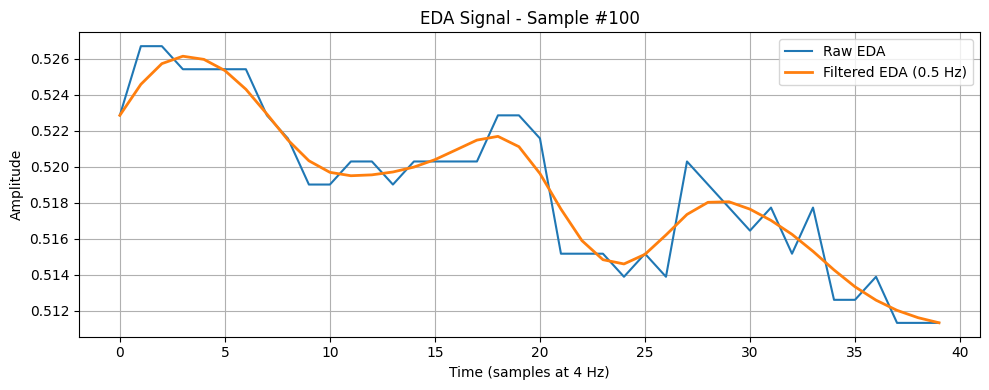

In [19]:
# Set sample index here (e.g., 42 or any between 0 and 21408)
sample_idx = 100

raw = X_eda[sample_idx, 0, :]
filtered = X_eda_filtered[sample_idx, 0, :]

plt.figure(figsize=(10, 4))
plt.plot(raw, label='Raw EDA')
plt.plot(filtered, label='Filtered EDA (0.5 Hz)', linewidth=2)
plt.title(f'EDA Signal - Sample #{sample_idx}')
plt.xlabel('Time (samples at 4 Hz)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\suyas\SVSNet\Preprocessing\EDA preprocessing\EDA_unprocessed_vs_filtered_sample.png")
plt.show()


In [20]:
# Detrending
import numpy as np
from scipy.signal import detrend

# Step 1: Identify valid EDA samples (no NaN or Inf)
valid_mask = np.all(np.isfinite(X_eda_filtered[:, 0, :]), axis=1)  # shape (N,)

# Step 2: Filter out invalid samples
X_eda_filtered_clean = X_eda_filtered[valid_mask]

# Step 3: Apply detrending
X_eda_detrended = np.array([detrend(sample[0]) for sample in X_eda_filtered_clean])
X_eda_detrended = X_eda_detrended[:, np.newaxis, :]

print(f"✅ Detrending complete. Valid samples: {X_eda_detrended.shape[0]}/{X_eda_filtered.shape[0]}")


✅ Detrending complete. Valid samples: 35954/35954


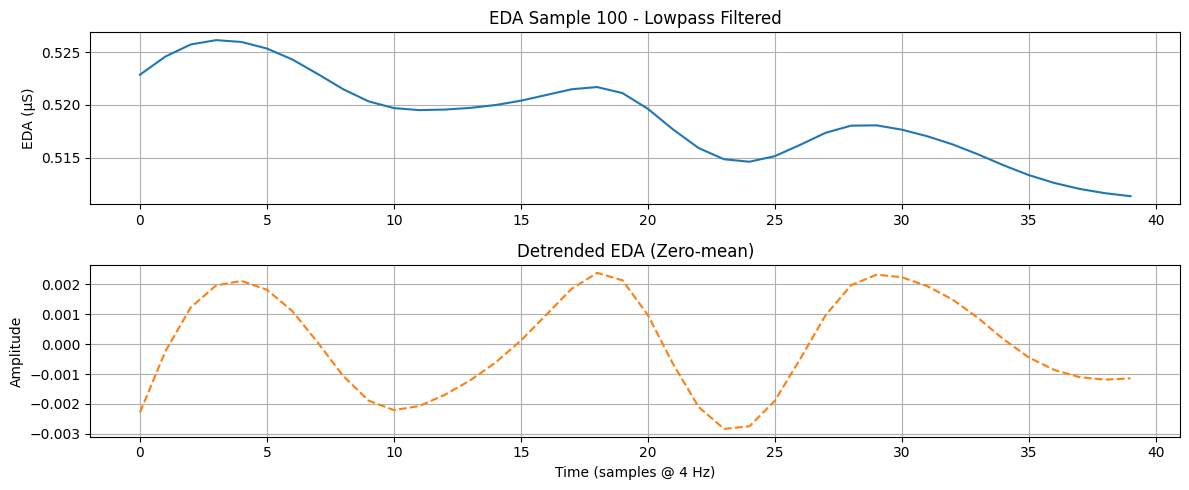

In [21]:
import matplotlib.pyplot as plt

def plot_detrend_comparison(idx):
    raw = X_eda_filtered_clean[idx][0]
    detr = X_eda_detrended[idx][0]

    plt.figure(figsize=(12, 5))

    # Plot 1: Lowpass Filtered
    plt.subplot(2, 1, 1)
    plt.plot(raw, label="Lowpass Filtered", color='tab:blue')
    plt.title(f"EDA Sample {idx} - Lowpass Filtered")
    plt.ylabel("EDA (μS)")
    plt.grid(True)

    # Plot 2: Detrended
    plt.subplot(2, 1, 2)
    plt.plot(detr, label="Detrended", color='tab:orange', linestyle='--')
    plt.title("Detrended EDA (Zero-mean)")
    plt.xlabel("Time (samples @ 4 Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(r"C:\Users\suyas\SVSNet\Preprocessing\EDA preprocessing\EDA_lowpassed_and_Detrended_sample.png")
    plt.show()

# Example usage
plot_detrend_comparison(100)


In [22]:
# Removing samples with NaNs and infs in BOTH EEG and EDA

# Identify valid (finite) samples
valid_indices = [i for i, x in enumerate(X_eda_detrended) if np.isfinite(x).all()]

# Apply the same filtering to all modalities and labels
X_eeg_denoised = X_eeg_denoised[valid_indices]
X_eda_detrended = X_eda_detrended[valid_indices]
y = y[valid_indices]

print(f"✅ Cleaned dataset: EEG {X_eeg_denoised.shape}, EDA {X_eda_detrended.shape}, Labels {y.shape}")


✅ Cleaned dataset: EEG (35954, 4, 2560), EDA (35954, 1, 40), Labels (35954,)


In [23]:
# Smoothing the Signal
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import numpy as np

# --- Parameters ---
window_length = 7   # Must be odd and <= EDA length (e.g., 7 for 40 samples at 4 Hz)
polyorder = 2       # Typically 2 or 3 works well for EDA

# --- Apply Savitzky–Golay smoothing ---
X_eda_smoothed = savgol_filter(X_eda_detrended, window_length=window_length, polyorder=polyorder, axis=2)

print("✅ Smoothing complete.")


✅ Smoothing complete.


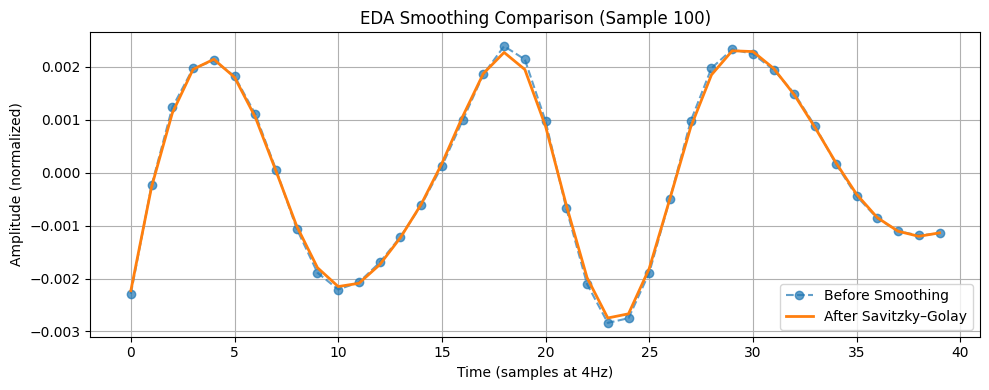

In [24]:
sample_idx = 100  # Change this to explore different samples

plt.figure(figsize=(10, 4))
plt.plot(X_eda_detrended[sample_idx, 0], label="Before Smoothing", linestyle='--', marker='o', alpha=0.7)
plt.plot(X_eda_smoothed[sample_idx, 0], label="After Savitzky–Golay", linewidth=2)
plt.title(f"EDA Smoothing Comparison (Sample {sample_idx})")
plt.xlabel("Time (samples at 4Hz)")
plt.ylabel("Amplitude (normalized)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\suyas\SVSNet\Preprocessing\EDA preprocessing\EDA_Smoothened_sample.png")
plt.show()


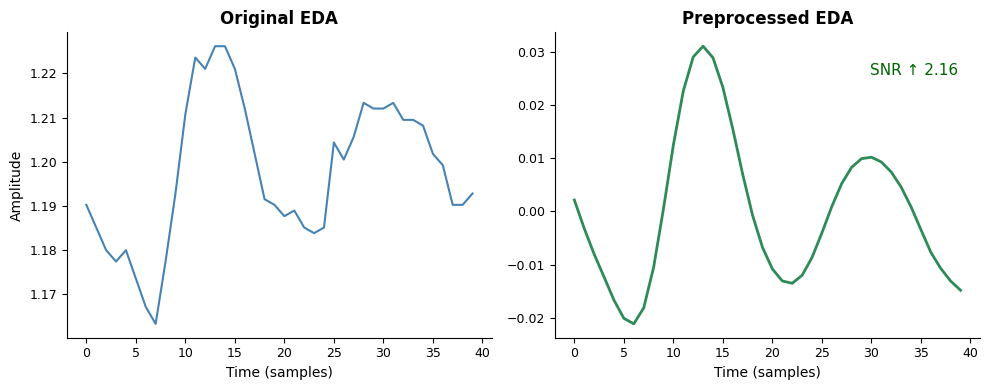

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def compare_eda_signals(X_eda, X_eda_smoothed, index=0, snr_db=False):
    """
    Compare raw vs. preprocessed EDA signal for a given sample index.
    
    Parameters:
        X_eda : np.ndarray, shape (N, 1, T) - Original EDA signals
        X_eda_smoothed : np.ndarray, shape (N, 1, T) - Preprocessed EDA signals
        index : int - Sample index to visualize
        snr_db : bool - Whether to display SNR in decibels
    """
    eda_orig = X_eda[index, 0]
    eda_proc = X_eda_smoothed[index, 0]
    time = np.arange(eda_orig.size)

    # --- SNR Calculation ---
    signal_power = np.std(eda_proc)
    noise_power = np.std(eda_orig - eda_proc) + 1e-6
    snr_value = 10 * np.log10(signal_power / noise_power) if snr_db else signal_power / noise_power
    snr_str = f"{snr_value:.2f} dB" if snr_db else f"{snr_value:.2f}"

    # --- Plotting ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

    # Original
    axes[0].plot(time, eda_orig, color='steelblue', lw=1.5)
    axes[0].set_title("Original EDA", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Time (samples)", fontsize=10)
    axes[0].set_ylabel("Amplitude", fontsize=10)
    axes[0].tick_params(labelsize=9)

    # Preprocessed
    axes[1].plot(time, eda_proc, color='seagreen', lw=2)
    axes[1].set_title("Preprocessed EDA", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Time (samples)", fontsize=10)
    axes[1].tick_params(labelsize=9)
    axes[1].text(0.95, 0.9, f"SNR ↑ {snr_str}", transform=axes[1].transAxes,
                 fontsize=11, ha='right', va='top', color='darkgreen')

    # Style
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 1])
    plt.savefig(r"C:\Users\suyas\SVSNet\Preprocessing\EDA preprocessing\EDA_unprocessed_vs_processed_sample.png")
    plt.show()

# Example usage:
compare_eda_signals(X_eda, X_eda_smoothed, index=50)


# BVP Preprocessing

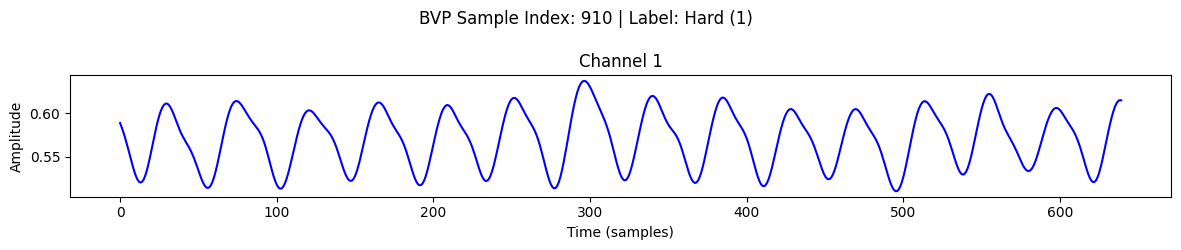

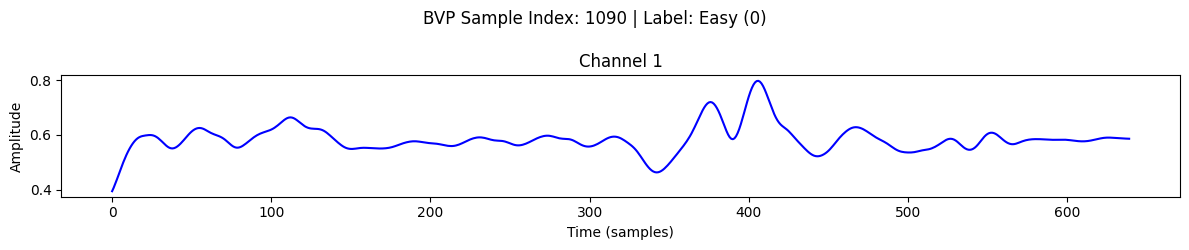

In [26]:
# Initial structure of unprocessed bvp

import matplotlib.pyplot as plt
import numpy as np

def plot_bvp_sample(X_bvp, y, index=0):
    bvp_sample = X_bvp[index]  # shape: (channels, time)
    label = y[index]
    num_channels = bvp_sample.shape[0]

    plt.figure(figsize=(12, 2.5 * num_channels))
    for i in range(num_channels):
        plt.subplot(num_channels, 1, i + 1)
        plt.plot(bvp_sample[i], color='b')
        plt.title(f"Channel {i+1}")
        plt.ylabel("Amplitude")
        if i == 0:
            plt.suptitle(f"BVP Sample Index: {index} | Label: {'Easy (0)' if label == 0 else 'Hard (1)'}")

    plt.xlabel("Time (samples)")
    plt.tight_layout()
    plt.savefig(r"C:\Users\suyas\SVSNet\Preprocessing\BVP preprocessing\BVP_Unprocessed_sample.png")
    plt.show()


# View a few samples
plot_bvp_sample(X_bvp, y, index=910)
plot_bvp_sample(X_bvp, y, index=1090)


In [27]:

from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

def bandpass_filter_bvp(signal, lowcut=0.5, highcut=8.0, fs=64, order=3):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, signal)

# Apply to all
X_bvp_filtered = np.array([
    [bandpass_filter_bvp(sample[0])] for sample in X_bvp
])


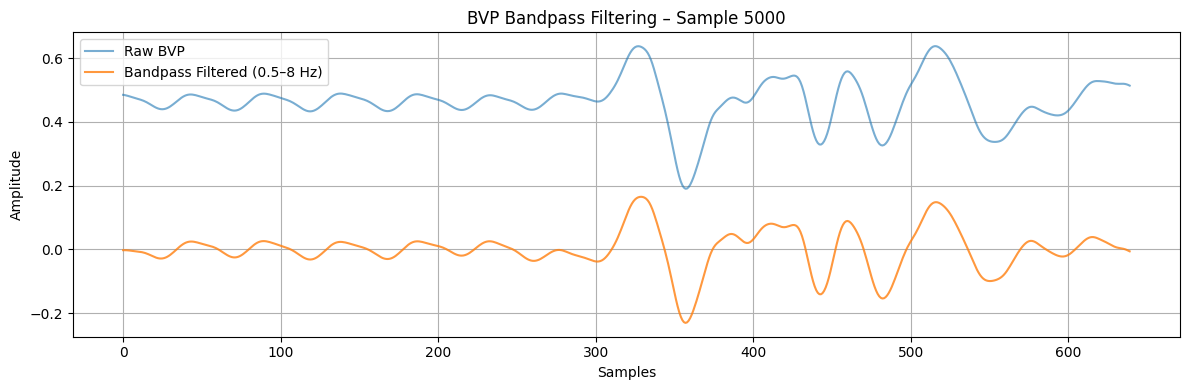

In [29]:
sample_index = 5000  # Change if needed
# Visualize
plt.figure(figsize=(12, 4))
plt.plot(X_bvp[sample_index, 0], label='Raw BVP', alpha=0.6)
plt.plot(X_bvp_filtered[sample_index, 0], label='Bandpass Filtered (0.5–8 Hz)', alpha=0.8)
plt.title(f"BVP Bandpass Filtering – Sample {sample_index}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\suyas\SVSNet\Preprocessing\BVP preprocessing\BVP_Bandpassed_sample.png")
plt.show()

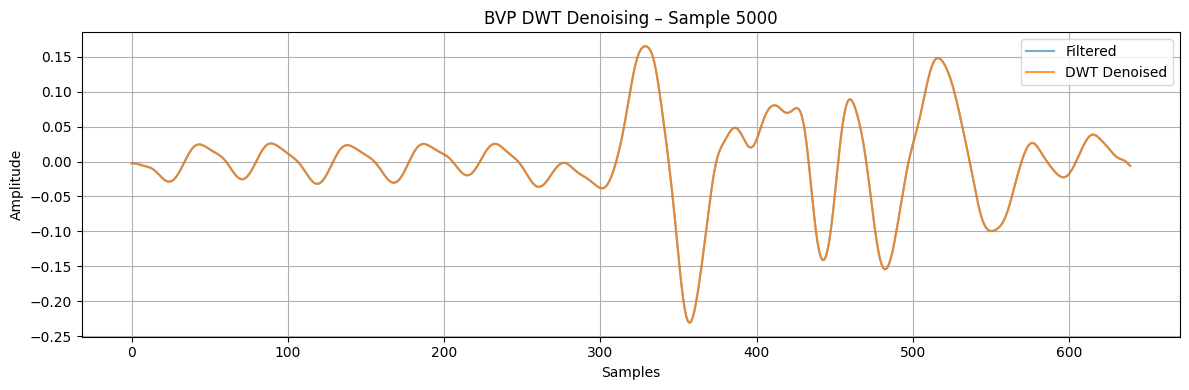

In [30]:
import pywt

def dwt_denoise_bvp(signal, wavelet='db4', level=3):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))
    coeffs_thresh = [coeffs[0]] + [pywt.threshold(c, uthresh, mode='soft') for c in coeffs[1:]]
    return pywt.waverec(coeffs_thresh, wavelet)[:len(signal)]

X_bvp_denoised = np.array([
    [dwt_denoise_bvp(sample[0])] for sample in X_bvp_filtered
])

# Visualize
plt.figure(figsize=(12, 4))
plt.plot(X_bvp_filtered[sample_index, 0], label='Filtered', alpha=0.6)
plt.plot(X_bvp_denoised[sample_index, 0], label='DWT Denoised', alpha=0.8)
plt.title(f"BVP DWT Denoising – Sample {sample_index}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\suyas\SVSNet\Preprocessing\BVP preprocessing\BVP_Denoised_sample.png")
plt.show()


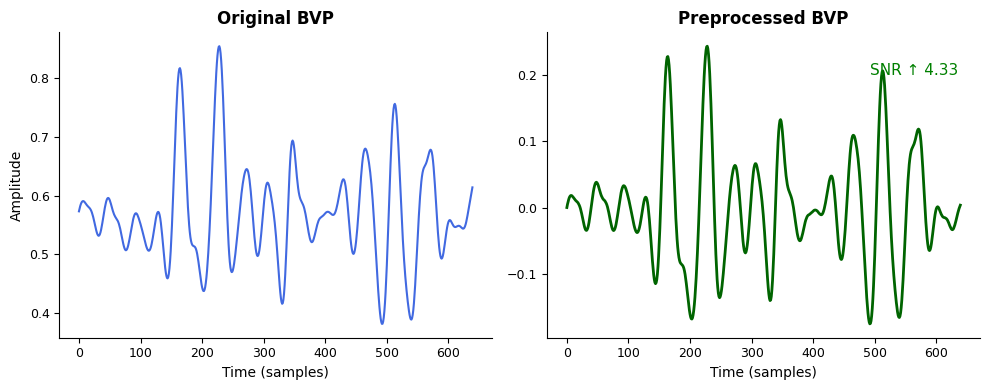

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def compare_bvp_signals(X_bvp_raw, X_bvp_denoised, index=0, snr_db=False):
    """
    Compare raw and preprocessed (filtered + denoised) BVP signals.

    Parameters:
        X_bvp_raw : np.ndarray, shape (N, 1, T) - Original BVP
        X_bvp_denoised : np.ndarray, shape (N, 1, T) - Preprocessed BVP
        index : int - Sample index to visualize
        snr_db : bool - Display SNR in decibels if True
    """
    bvp_orig = X_bvp_raw[index, 0]
    bvp_proc = X_bvp_denoised[index, 0]
    time = np.arange(bvp_orig.size)

    # --- SNR Calculation ---
    signal_power = np.std(bvp_proc)
    noise_power = np.std(bvp_orig - bvp_proc) + 1e-6
    snr = 10 * np.log10(signal_power / noise_power) if snr_db else signal_power / noise_power
    snr_str = f"{snr:.2f} dB" if snr_db else f"{snr:.2f}"

    # --- Plotting ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

    axes[0].plot(time, bvp_orig, color='royalblue', lw=1.5)
    axes[0].set_title("Original BVP", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Time (samples)", fontsize=10)
    axes[0].set_ylabel("Amplitude", fontsize=10)
    axes[0].tick_params(labelsize=9)

    axes[1].plot(time, bvp_proc, color='darkgreen', lw=2)
    axes[1].set_title("Preprocessed BVP", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Time (samples)", fontsize=10)
    axes[1].tick_params(labelsize=9)
    axes[1].text(0.95, 0.9, f"SNR ↑ {snr_str}", transform=axes[1].transAxes,
                 fontsize=11, ha='right', va='top', color='green')

    # Style
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(r"C:\Users\suyas\SVSNet\Preprocessing\BVP preprocessing\BVP_Unprocessed_vs_Preprocessed_sample.png")
    plt.show()

compare_bvp_signals(X_bvp, X_bvp_denoised, index=900)


# TEMP Processing

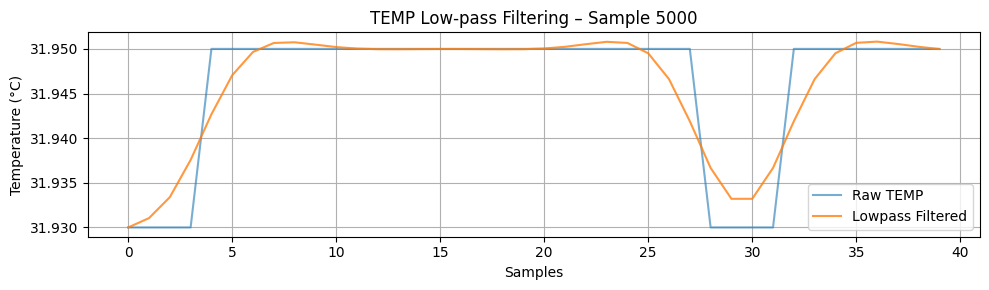

In [32]:
sample_index = 5000  # You can change this if needed
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

def lowpass_filter_temp(signal, cutoff=0.5, fs=4, order=2):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff / nyq, btype='low')
    return filtfilt(b, a, signal)

# Apply filter
X_temp_filtered = np.array([
    [lowpass_filter_temp(sample[0])] for sample in X_temp
])

# Visualize
plt.figure(figsize=(10, 3))
plt.plot(X_temp[sample_index, 0], label="Raw TEMP", alpha=0.6)
plt.plot(X_temp_filtered[sample_index, 0], label="Lowpass Filtered", alpha=0.8)
plt.title(f"TEMP Low-pass Filtering – Sample {sample_index}")
plt.xlabel("Samples")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\suyas\SVSNet\Preprocessing\TEMP Preprocessing\TEMP_unprocessed_vs_lowpassed_sample.png")
plt.show()


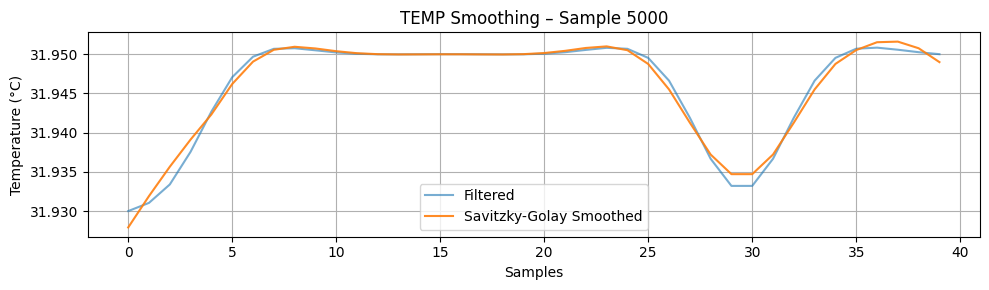

In [35]:
from scipy.signal import savgol_filter

def smooth_temp_savgol(signal, window_length=9, polyorder=2):
    return savgol_filter(signal, window_length=window_length, polyorder=polyorder)

# Apply smoothing
X_temp_smoothed = np.array([
    [smooth_temp_savgol(sample[0])] for sample in X_temp_filtered
])

# Visualize
plt.figure(figsize=(10, 3))
plt.plot(X_temp_filtered[sample_index, 0], label="Filtered", alpha=0.6)
plt.plot(X_temp_smoothed[sample_index, 0], label="Savitzky-Golay Smoothed", alpha=0.9)
plt.title(f"TEMP Smoothing – Sample {sample_index}")
plt.xlabel("Samples")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\suyas\SVSNet\Preprocessing\TEMP Preprocessing\TEMP_Filtered_vs_Smoothened_sample.png")
plt.show()


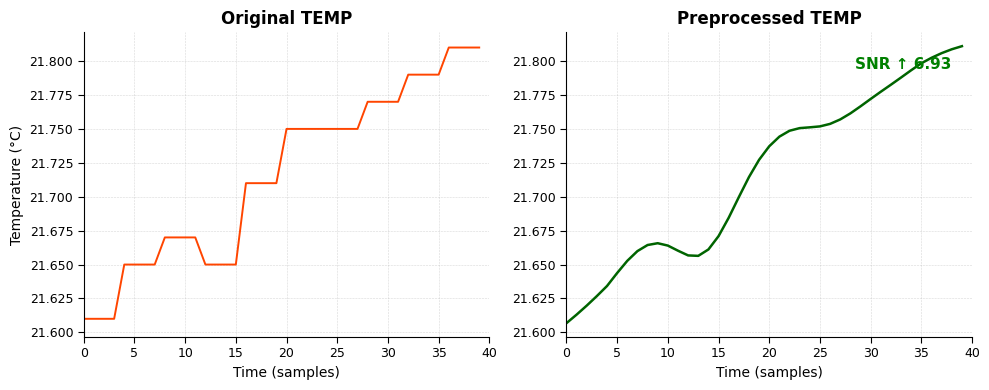

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def compare_temp_signals(X_temp_raw, X_temp_smoothed, index=5000, snr_db=False):
    """
    Compare raw and preprocessed (filtered + smoothed) TEMP signals.
    """
    temp_orig = X_temp_raw[index, 0]
    temp_proc = X_temp_smoothed[index, 0]
    time = np.arange(temp_orig.size)

    # --- SNR Calculation ---
    signal_power = np.std(temp_proc)
    noise_power = np.std(temp_orig - temp_proc) + 1e-6
    snr = 10 * np.log10(signal_power / noise_power) if snr_db else signal_power / noise_power
    snr_str = f"{snr:.2f} dB" if snr_db else f"{snr:.2f}"

    # --- Axis ranges ---
    min_val = min(temp_orig.min(), temp_proc.min())
    max_val = max(temp_orig.max(), temp_proc.max())
    y_margin = (max_val - min_val) * 0.05

    # --- Plotting ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

    # Raw TEMP
    axes[0].plot(time, temp_orig, color='orangered', lw=1.4)
    axes[0].set_title("Original TEMP", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Time (samples)", fontsize=10)
    axes[0].set_ylabel("Temperature (°C)", fontsize=10)
    axes[0].tick_params(labelsize=9, length=4, width=0.8)
    axes[0].grid(True, linestyle='--', linewidth=0.4, alpha=0.5)
    axes[0].set_ylim(min_val - y_margin, max_val + y_margin)
    axes[0].set_xlim(0, len(time))

    # Preprocessed TEMP
    axes[1].plot(time, temp_proc, color='darkgreen', lw=1.8)
    axes[1].set_title("Preprocessed TEMP", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Time (samples)", fontsize=10)
    axes[1].tick_params(labelsize=9, length=4, width=0.8)
    axes[1].grid(True, linestyle='--', linewidth=0.4, alpha=0.5)
    axes[1].set_ylim(min_val - y_margin, max_val + y_margin)
    axes[1].set_xlim(0, len(time))
    axes[1].text(0.95, 0.92, f"SNR ↑ {snr_str}", transform=axes[1].transAxes,
                 fontsize=11, ha='right', va='top', color='green', fontweight='bold')

    # Style
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(r"C:\Users\suyas\SVSNet\Preprocessing\TEMP Preprocessing\TEMP_unprocessed_vs_preprocessed_sample.png")
    plt.show()

# Example usage
compare_temp_signals(X_temp, X_temp_smoothed, index=16443)


### Normalization

In [37]:
# EEG: shape (N, 4, 2560)
X_eeg_final = (X_eeg_denoised - X_eeg_denoised.mean(axis=2, keepdims=True)) / \
              (X_eeg_denoised.std(axis=2, keepdims=True) + 1e-6)

# EDA: shape (N, 1, 40)
X_eda_final = (X_eda_smoothed - X_eda_smoothed.mean(axis=2, keepdims=True)) / \
              (X_eda_smoothed.std(axis=2, keepdims=True) + 1e-6)

# BVP: shape (N, 1, 640)
X_bvp_final = (X_bvp_filtered - X_bvp_filtered.mean(axis=2, keepdims=True)) / \
              (X_bvp_filtered.std(axis=2, keepdims=True) + 1e-6)

# TEMP: shape (N, 1, 40)
X_temp_final = (X_temp_smoothed - X_temp_smoothed.mean(axis=2, keepdims=True)) / \
               (X_temp_smoothed.std(axis=2, keepdims=True) + 1e-6)

print("✅ Final normalization complete for EEG, EDA, BVP, and TEMP.")


✅ Final normalization complete for EEG, EDA, BVP, and TEMP.


In [38]:
print(X_eeg_final.shape, X_eda_final.shape,X_bvp_final.shape,X_temp_final.shape, y.shape)

(35954, 4, 2560) (35954, 1, 40) (35954, 1, 640) (35954, 1, 40) (35954,)


### TRAIN TEST SPLIT

In [39]:
import torch
from sklearn.model_selection import train_test_split
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Ensure float labels for BCELoss or torch operations
y = y.astype(np.float32)

# Train-test split for all four signals
X_eeg_train, X_eeg_test, \
X_eda_train, X_eda_test, \
X_bvp_train, X_bvp_test, \
X_temp_train, X_temp_test, \
y_train, y_test = train_test_split(
    X_eeg_final, X_eda_final, X_bvp_final, X_temp_final, y,
    test_size=0.2, stratify=y, random_state=42
)

# Check label distribution
print("✅ Split complete.")
print("Train labels:", np.unique(y_train, return_counts=True))
print("Test labels:", np.unique(y_test, return_counts=True))


Using device: cuda
✅ Split complete.
Train labels: (array([0., 1.], dtype=float32), array([14753, 14010]))
Test labels: (array([0., 1.], dtype=float32), array([3688, 3503]))


### Data Loader Creation

In [40]:
from torch.utils.data import Dataset, DataLoader
import torch

class EEG_EDA_BVP_TEMP_Dataset(Dataset):
    def __init__(self, eeg, eda, bvp, temp, labels):
        self.eeg = torch.tensor(eeg, dtype=torch.float32)
        self.eda = torch.tensor(eda, dtype=torch.float32)
        self.bvp = torch.tensor(bvp, dtype=torch.float32)
        self.temp = torch.tensor(temp, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'eeg': self.eeg[idx],
            'eda': self.eda[idx],
            'bvp': self.bvp[idx],
            'temp': self.temp[idx],
            'label': self.labels[idx]
        }
batch_size = 64

train_dataset = EEG_EDA_BVP_TEMP_Dataset(
    X_eeg_train, X_eda_train, X_bvp_train, X_temp_train, y_train
)

test_dataset = EEG_EDA_BVP_TEMP_Dataset(
    X_eeg_test, X_eda_test, X_bvp_test, X_temp_test, y_test
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# SVSNet Detailed Architecture 

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AttentionBlock(nn.Module):
    def __init__(self, input_dim):
        super(AttentionBlock, self).__init__()
        self.attn = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.Tanh(),
            nn.Linear(input_dim, 1)
        )
        self.attn_weights = None  # Store weights
    def forward(self, x):  # x: (B, T, D)
        weights = self.attn(x)  # (B, T, 1)
        weights = F.softmax(weights, dim=1)
        self.attn_weights = weights  # <--- Store here
        weighted = x * weights  # (B, T, D)
        return weighted.sum(dim=1)  # (B, D)


In [42]:
class EEGNet(nn.Module):
    def __init__(self, num_channels=4, num_samples=7680, dropout_rate=0.25, F1=8, D=2, F2=16, kernel_length=64):
        super(EEGNet, self).__init__()
        self.firstconv = nn.Sequential(
            nn.Conv2d(1, F1, (1, kernel_length), padding=(0, kernel_length // 2), bias=False),
            nn.BatchNorm2d(F1)
        )
        self.depthwiseConv = nn.Sequential(
            nn.Conv2d(F1, F1 * D, (num_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout_rate)
        )
        self.separableConv = nn.Sequential(
            nn.Conv2d(F1 * D, F2, (1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout_rate)
        )

    def forward(self, x):  # x: (B, C=4, T)
        x = x.unsqueeze(1)              # (B, 1, 4, T)
        x = self.firstconv(x)           # (B, F1, 4, T)
        x = self.depthwiseConv(x)       # (B, F1*D, 1, T//4)
        x = self.separableConv(x)       # (B, F2, 1, T//32)
        x = x.squeeze(2).permute(0, 2, 1)  # (B, T', F2)
        return x  # Return for BiLSTM


In [43]:
import torch.nn as nn
import torch.nn.functional as F
class EEG_EDA_BVP_TEMP_Model(nn.Module):
    def __init__(self, eeg_input_len, eda_input_len, bvp_input_len, temp_input_len):
        super(EEG_EDA_BVP_TEMP_Model, self).__init__()

        # === EEG branch ===
        self.eeg_net = EEGNet(num_channels=4, num_samples=eeg_input_len)
        self.eeg_bilstm = nn.LSTM(input_size=16, hidden_size=32, batch_first=True, bidirectional=True, num_layers=2, dropout=0.3)
        self.eeg_attn = AttentionBlock(input_dim=64)

        # === EDA branch ===
        self.eda_cnn = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=3, padding=1),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.MaxPool1d(2),
            nn.Conv1d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.MaxPool1d(2)
        )
        self.eda_bilstm = nn.LSTM(input_size=16, hidden_size=16, batch_first=True, bidirectional=True, num_layers=2, dropout=0.3)
        self.eda_attn = AttentionBlock(input_dim=32)

        # === BVP branch ===
        self.bvp_cnn = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=3, padding=1),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.MaxPool1d(2),
            nn.Conv1d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.MaxPool1d(2)
        )
        self.bvp_bilstm = nn.LSTM(input_size=16, hidden_size=16, batch_first=True, bidirectional=True, num_layers=2, dropout=0.3)
        self.bvp_attn = AttentionBlock(input_dim=32)

        # === TEMP branch ===
        self.temp_cnn = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=3, padding=1),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.MaxPool1d(2),
            nn.Conv1d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.MaxPool1d(2)
        )
        self.temp_bilstm = nn.LSTM(input_size=16, hidden_size=16, batch_first=True, bidirectional=True, num_layers=2, dropout=0.3)
        self.temp_attn = AttentionBlock(input_dim=32)

        # === Fusion ===
        self.fc1 = nn.Linear(64 + 32 + 32 + 32, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, eeg, eda, bvp, temp):
        # === EEG ===
        eeg_feat = self.eeg_net(eeg)            # (B, T', 16)
        eeg_feat, _ = self.eeg_bilstm(eeg_feat) # (B, T', 64)
        eeg_feat = self.eeg_attn(eeg_feat)      # (B, 64)

        # === EDA ===
        eda_feat = self.eda_cnn(eda)            # (B, 16, T')
        eda_feat = eda_feat.permute(0, 2, 1)    # (B, T', 16)
        eda_feat, _ = self.eda_bilstm(eda_feat) # (B, T', 32)
        eda_feat = self.eda_attn(eda_feat)      # (B, 32)

        # === BVP ===
        bvp_feat = self.bvp_cnn(bvp)
        bvp_feat = bvp_feat.permute(0, 2, 1)
        bvp_feat, _ = self.bvp_bilstm(bvp_feat)
        bvp_feat = self.bvp_attn(bvp_feat)

        # === TEMP ===
        temp_feat = self.temp_cnn(temp)
        temp_feat = temp_feat.permute(0, 2, 1)
        temp_feat, _ = self.temp_bilstm(temp_feat)
        temp_feat = self.temp_attn(temp_feat)

        # === Fusion + Classification ===
        combined = torch.cat([eeg_feat, eda_feat, bvp_feat, temp_feat], dim=1)  # (B, 160)
        x = F.relu(self.fc1(combined))  # (B, 128)
        x = self.dropout(x)
        x = self.fc2(x)  # (B, 1)
        return torch.sigmoid(x).squeeze(1)  # (B,)


### Training Pipeline

In [44]:
import torch
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# === Instantiate model ===
eeg_input_len = X_eeg_final.shape[-1]   # 2560
eda_input_len = X_eda_final.shape[-1]   # 40
bvp_input_len = X_bvp_final.shape[-1]   # 640
temp_input_len = X_temp_final.shape[-1] # 40

model = EEG_EDA_BVP_TEMP_Model(
    eeg_input_len, eda_input_len, bvp_input_len, temp_input_len
).to(device)

criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 200
best_test_acc = 0.0

train_acc_list = []
train_f1_list = []
test_acc_list = []
test_f1_list = []

for epoch in range(1, num_epochs + 1):
    model.train()
    train_preds, train_labels = [], []

    for batch in train_loader:
        eeg_batch = batch['eeg'].to(device)
        eda_batch = batch['eda'].to(device)
        bvp_batch = batch['bvp'].to(device)
        temp_batch = batch['temp'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(eeg_batch, eda_batch, bvp_batch, temp_batch)
        outputs = torch.clamp(outputs, 1e-7, 1 - 1e-7)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = (outputs.detach().cpu().numpy() > 0.5).astype(int)
        train_preds.extend(preds)
        train_labels.extend(labels.cpu().numpy())

    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds)
    train_acc_list.append(train_acc)
    train_f1_list.append(train_f1)
    print(f"[Epoch {epoch:02d}] Train Loss: {loss.item():.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")

    # === Evaluation ===
    model.eval()
    test_preds, test_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            eeg_batch = batch['eeg'].to(device)
            eda_batch = batch['eda'].to(device)
            bvp_batch = batch['bvp'].to(device)
            temp_batch = batch['temp'].to(device)
            labels = batch['label'].to(device)

            outputs = model(eeg_batch, eda_batch, bvp_batch, temp_batch)
            outputs = torch.clamp(outputs, 1e-7, 1 - 1e-7)
            preds = (outputs.cpu().numpy() > 0.5).astype(int)

            test_preds.extend(preds)
            test_labels.extend(labels.cpu().numpy())

    test_acc = accuracy_score(test_labels, test_preds)
    test_f1 = f1_score(test_labels, test_preds)
    test_acc_list.append(test_acc)
    test_f1_list.append(test_f1)
    print(f"👉 Eval @ Epoch {epoch:02d} | Test Acc: {test_acc:.4f} | F1: {test_f1:.4f}")

    # Save best model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"✅ Saved new best model at Epoch {epoch} with Test Acc: {test_acc:.4f}")


Using device: cuda
[Epoch 01] Train Loss: 0.6328 | Acc: 0.6240 | F1: 0.6437
👉 Eval @ Epoch 01 | Test Acc: 0.6849 | F1: 0.6846
✅ Saved new best model at Epoch 1 with Test Acc: 0.6849
[Epoch 02] Train Loss: 0.6932 | Acc: 0.6698 | F1: 0.6782
👉 Eval @ Epoch 02 | Test Acc: 0.6934 | F1: 0.6702
✅ Saved new best model at Epoch 2 with Test Acc: 0.6934
[Epoch 03] Train Loss: 0.5968 | Acc: 0.6912 | F1: 0.6966
👉 Eval @ Epoch 03 | Test Acc: 0.7290 | F1: 0.7294
✅ Saved new best model at Epoch 3 with Test Acc: 0.7290
[Epoch 04] Train Loss: 0.6577 | Acc: 0.7067 | F1: 0.7110
👉 Eval @ Epoch 04 | Test Acc: 0.6939 | F1: 0.6216
[Epoch 05] Train Loss: 0.4061 | Acc: 0.7204 | F1: 0.7243
👉 Eval @ Epoch 05 | Test Acc: 0.7508 | F1: 0.7613
✅ Saved new best model at Epoch 5 with Test Acc: 0.7508
[Epoch 06] Train Loss: 0.5287 | Acc: 0.7327 | F1: 0.7341
👉 Eval @ Epoch 06 | Test Acc: 0.7534 | F1: 0.7638
✅ Saved new best model at Epoch 6 with Test Acc: 0.7534
[Epoch 07] Train Loss: 0.6257 | Acc: 0.7427 | F1: 0.7431
👉 

## Result and Visualization

### Training vs Validation curves of Accuracy and F1 score

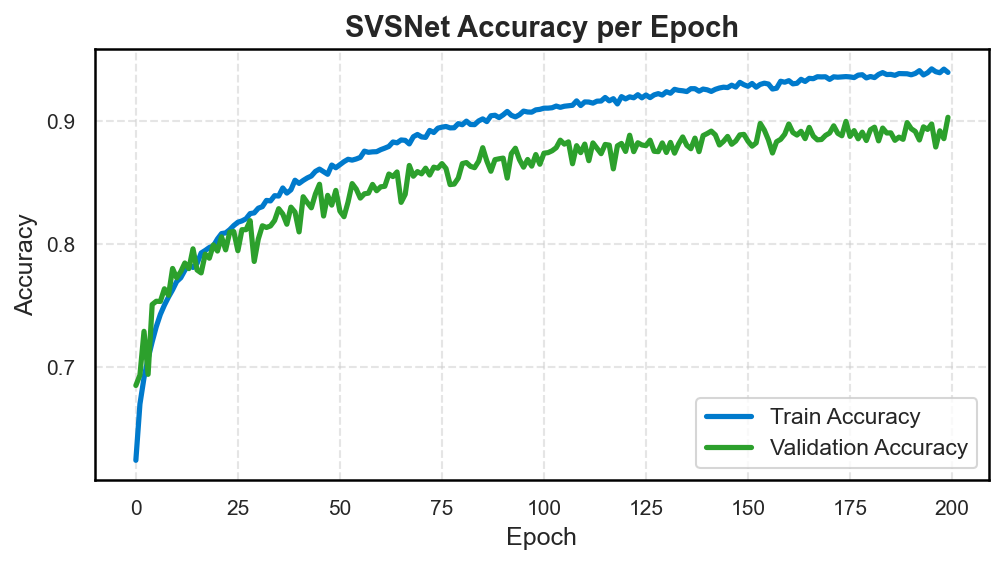

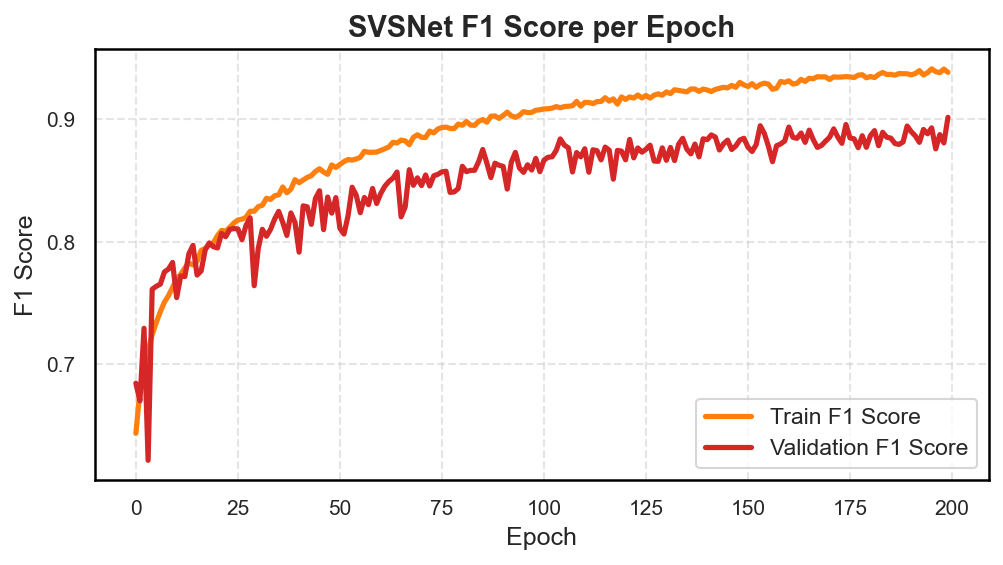

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for publication-quality plots
sns.set(style='whitegrid', font_scale=1.2)
plt.rcParams['axes.edgecolor'] = '0'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 150

# Colors
train_color_acc = '#007acc'     # Soft blue
val_color_acc = '#2ca02c'       # Green
train_color_f1 = '#ff7f0e'      # Orange
val_color_f1 = '#d62728'        # Red

# === Accuracy Plot ===
plt.figure(figsize=(7, 4))
plt.plot(train_acc_list[:200], label='Train Accuracy', color=train_color_acc, linewidth=2.5, linestyle='-')
plt.plot(test_acc_list[:200], label='Validation Accuracy', color=val_color_acc, linewidth=2.5, linestyle='-')
plt.title("SVSNet Accuracy per Epoch", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(r"C:\Users\suyas\SVSNet\Results\Accuracy_per_epoch.png")
plt.show()

# === F1 Score Plot ===
plt.figure(figsize=(7, 4))
plt.plot(train_f1_list[:200], label='Train F1 Score', color=train_color_f1, linewidth=2.5, linestyle='-')
plt.plot(test_f1_list[:200], label='Validation F1 Score', color=val_color_f1, linewidth=2.5, linestyle='-')
plt.title("SVSNet F1 Score per Epoch", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("F1 Score", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(r"C:\Users\suyas\SVSNet\Results\F1_per_epoch.png")
plt.show()


### Confusion Matrix

In [48]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        eeg = batch['eeg'].to(device)
        eda = batch['eda'].to(device)
        bvp = batch['bvp'].to(device)
        temp = batch['temp'].to(device)
        labels = batch['label'].to(device).float()  # binary: float for BCELoss

        outputs = model(eeg, eda, bvp, temp)  # shape: (B,) after sigmoid

        preds = (outputs > 0.5).int()  # Binary threshold at 0.5

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


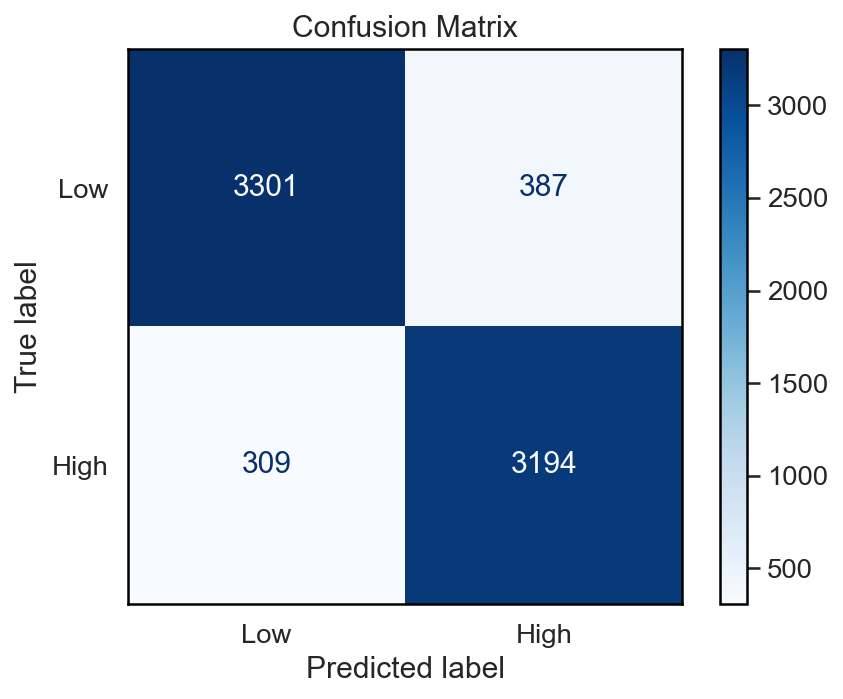

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "High"])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.grid(False)
plt.savefig(r"C:\Users\suyas\SVSNet\Results\CM.png")
plt.show()


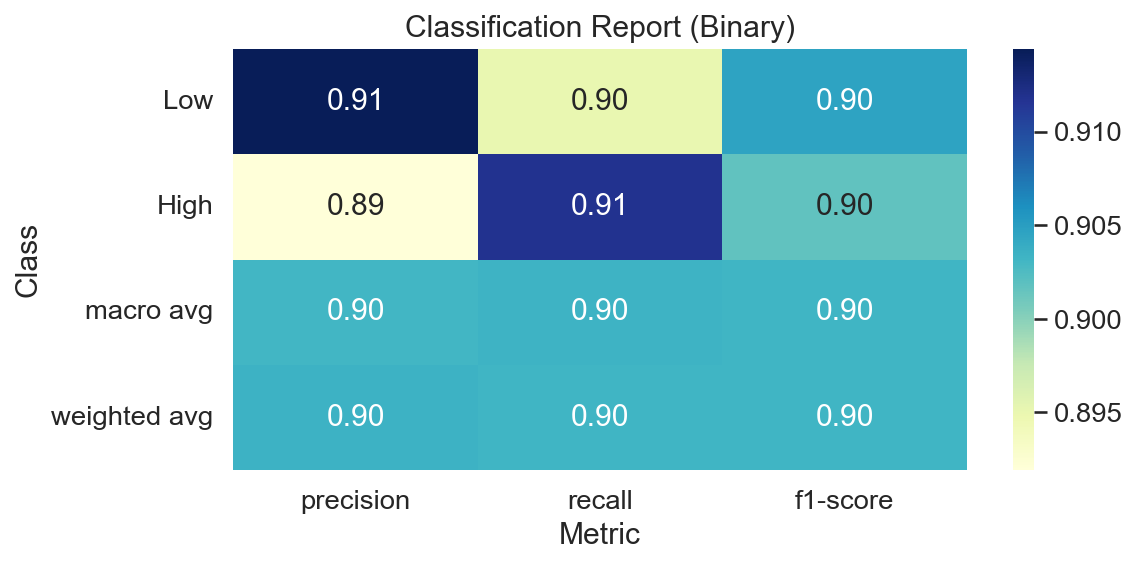

In [53]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generate report dictionary
report = classification_report(all_labels, all_preds, output_dict=True, target_names=["Low", "High"])

# Convert to DataFrame
df_report = pd.DataFrame(report).transpose()

# Drop 'accuracy' row if needed (or keep it)
df_report = df_report.drop(index=['accuracy'], errors='ignore')

# Plot heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:, :3], annot=True, fmt=".2f", cmap="YlGnBu", cbar=True)
plt.title("Classification Report (Binary)")
plt.ylabel("Class")
plt.xlabel("Metric")
plt.tight_layout()
plt.savefig(r"C:\Users\suyas\SVSNet\Results\Classification_Report.png")
plt.show()


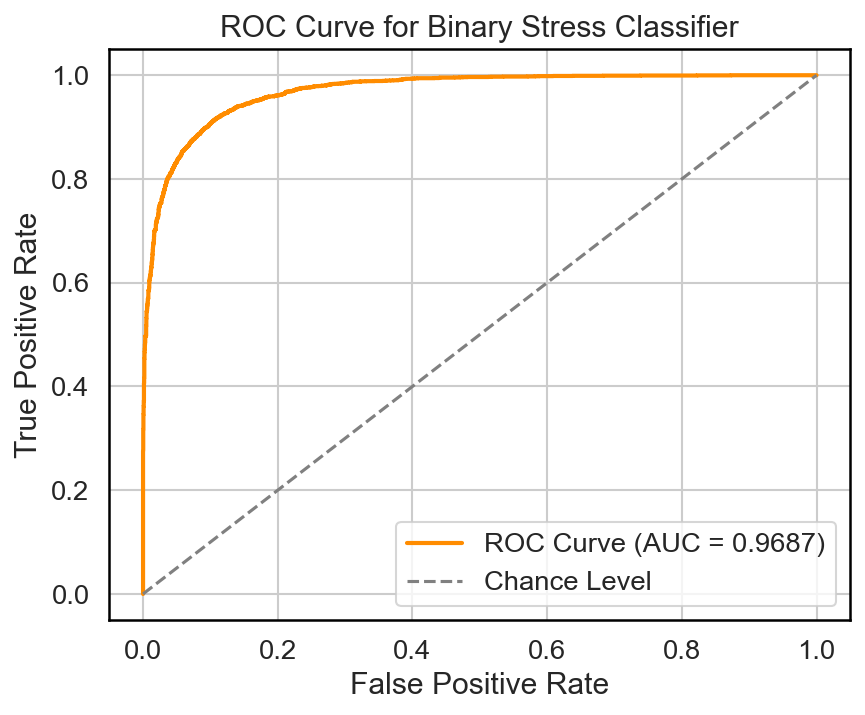

In [54]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Collect true labels and predicted probabilities
all_probs = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        eeg = batch['eeg'].to(device)
        eda = batch['eda'].to(device)
        bvp = batch['bvp'].to(device)
        temp = batch['temp'].to(device)
        labels = batch['label'].to(device)

        outputs = model(eeg, eda, bvp, temp)  # (B,) after sigmoid
        all_probs.extend(outputs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', color='darkorange', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance Level')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Binary Stress Classifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\suyas\SVSNet\Results\ROC_curve.png")
plt.show()
